# Learn the Simulation software


## Setup 

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('neutron_xray_sim').parent.resolve()))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10})
%matplotlib inline

import neutron_xray_sim as nxs
from neutron_xray_sim.io import SimCache
from neutron_xray_sim.histogram import (
    plot_cross_algorithm_grid,
    make_cross_algorithm_sinos,
    evaluate_histogram_quality,
    compare_algorithms,
)

print(f'neutron_xray_sim v{nxs.__version__} loaded.')
print('Available algorithms:', nxs.AVAILABLE_ALGORITHMS)
print('Available phantoms:  ', list(nxs.PHANTOM_PRESETS.keys()))

import requests


neutron_xray_sim v1.0.0 loaded.
Available algorithms: ['FBP', 'GRIDREC', 'SIRT', 'SART', 'CGLS', 'EM', 'OSSART', 'TV_MIN', 'NESTEROV_SIRT']
Available phantoms:   ['composite', 'battery', 'bone_implant', 'industrial']


## phantom constructiom 

In [2]:
# ── Global simulation parameters (shared by all sections below) ──────────
PRESET   = 'battery'   # 'composite' | 'battery' | 'bone_implant' | 'industrial'
N        = 512            # voxel grid (use 128–512 for publication quality)
N_ANGLES = 300           # projection angles (use 360–1200 for publication)

phantom = nxs.make_phantom(PRESET, N)
print(phantom)
print('Materials:', [m.name for m in phantom.materials])


PhantomData('battery', 512³, 0.002734375 cm/voxel, materials=[Air, Fe, H₂O, HDPE, Zn])
Materials: ['Air', 'Iron', 'Water', 'HDPE', 'Zinc']


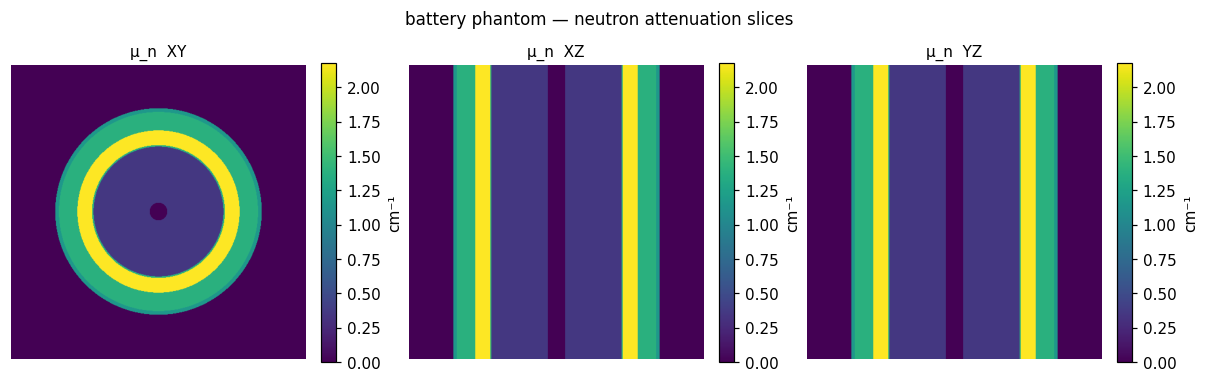

In [3]:
# ── Central orthogonal slices of the neutron attenuation volume ──────────
si = N // 2
slices = [
    ('μ_n  XY', phantom.mu_n_vol[si, :, :]),
    ('μ_n  XZ', phantom.mu_n_vol[:, si, :]),
    ('μ_n  YZ', phantom.mu_n_vol[:, :, si]),
]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, (title, sl) in zip(axes, slices):
    im = ax.imshow(sl, cmap='viridis', origin='lower')
    ax.set_title(title, fontsize=10); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label='cm⁻¹')
fig.suptitle(f'{PRESET} phantom — neutron attenuation slices', fontsize=11)
plt.tight_layout(); plt.show()


## create projections 

In [4]:
KVP       = 120.0
AL_FILTER = 2.0

xray_sino, neut_sino = nxs.make_sinogram_pair(
    phantom,
    n_angles        = N_ANGLES,
    angle_range_deg = 360.0,
    kVp             = KVP,
    filter_mm_Al    = AL_FILTER,
    n_spectrum_bins = 12,
    I0_xray         = 1e5,
    I0_neutron      = 1e5,
    use_astra       = True,
)
print('X-ray sinogram :', xray_sino['sino_lam'].shape,
      '  (n_angles, N_slice, N_det)')
print('Neutron sinogram:', neut_sino['sino_lam'].shape)


[projector] Projecting 300 angles (ASTRA GPU) …
  → X-ray (polychromatic) …
  → Neutron (thermal) …
[projector] Done.
X-ray sinogram : (300, 512, 512)   (n_angles, N_slice, N_det)
Neutron sinogram: (300, 512, 512)


### monochromatic projections 

In [18]:
xray_sino, neut_sino = nxs.make_sinogram_pair(
    phantom,
    n_angles=N_ANGLES,
    angle_range_deg=360.0,
    xray_mode="monochromatic",
    xray_energy_keV=80.0,
    I0_xray=1e5,
    I0_neutron=1e5,
    use_astra=True,
)

[projector] Projecting 300 angles (ASTRA GPU) …
  → X-ray (monochromatic, 80.0 keV) …
  → Neutron (thermal) …
[projector] Done.


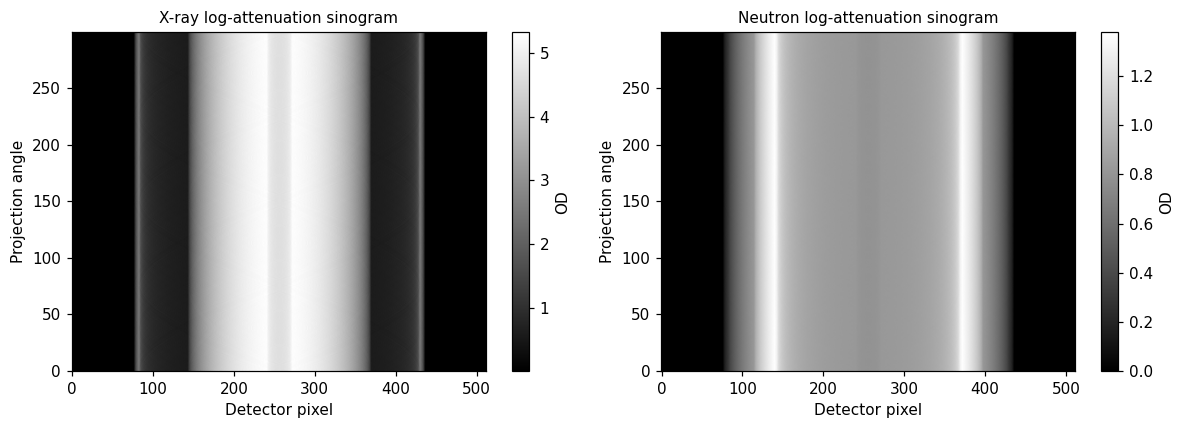

In [7]:
# ── Visualise central sinogram slices ─────────────────────────────────────
s = N // 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sino, title in zip(axes,
        [xray_sino['sino_lam'][:, s, :], neut_sino['sino_lam'][:, s, :]],
        ['X-ray log-attenuation sinogram', 'Neutron log-attenuation sinogram']):
    im = ax.imshow(sino, aspect='auto', cmap='gray', origin='lower')
    ax.set_xlabel('Detector pixel'); ax.set_ylabel('Projection angle')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='OD')
plt.tight_layout(); plt.show()


## CT reconstruction

In [19]:
# no artifact 
# ── Custom config ─────────────────────────────────────────────────────────
custom_cfg = nxs.ArtifactConfig(
    #photon_noise              = True,
    #I0_xray                   = 5e4,
    #I0_neutron                = 5e4,
    #neutron_scatter           = True,
    #scatter_fraction          = 0.06,
    #scatter_sigma_pixels      = 9.0,
    #detector_psf              = True,
    #psf_sigma_xray_pixels     = 0.8,
    #psf_sigma_neutron_pixels  = 1.5,
)
print('Custom config:', custom_cfg.summary())


Custom config: BH_artifact(no_correction)


In [20]:
from neutron_xray_sim.artifacts import inject_sinogram_artifacts, inject_volume_artifacts

# ── Inject sinogram-domain artifacts ──────────────────────────────────────
x_sino_art, n_sino_art = inject_sinogram_artifacts(
    {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in xray_sino.items()},
    {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in neut_sino.items()},
    custom_cfg,
)


In [21]:
# ── Choose algorithm and reconstruct ──────────────────────────────────────
ALGORITHM   = 'FBP'         # change to any of the nine algorithms above
FILTER_NAME = 'shepp-logan'  # for FBP / GRIDREC only
N_ITER      = 30             # for all iterative algorithms
N_SUBSETS   = 10             # for OSSART only
LAMBDA_TV   = 0.02           # for TV_MIN only

vol_x, vol_n = nxs.reconstruct_pair(
    x_sino_art, n_sino_art,
    algorithm    = ALGORITHM,
    filter_name  = FILTER_NAME,
    n_iter       = N_ITER,
    n_subsets    = N_SUBSETS,
    lambda_tv    = LAMBDA_TV,
    remove_rings = True,
    use_astra    = True,
    clip_negative= True,
)

# Apply volume-domain artifacts (misalignment etc.)
vol_x, vol_n = inject_volume_artifacts(vol_x, vol_n, custom_cfg)

print(f'vol_x: {vol_x.shape}  [{vol_x.min():.3f}, {vol_x.max():.3f}] cm⁻¹')
print(f'vol_n: {vol_n.shape}  [{vol_n.min():.3f}, {vol_n.max():.3f}] cm⁻¹')


[reconstructor] Reconstructing with FBP …
  -> X-ray …
  -> Neutron …
[reconstructor] Done.
vol_x: (512, 512, 512)  [0.000, 4.446] cm⁻¹
vol_n: (512, 512, 512)  [0.000, 2.255] cm⁻¹


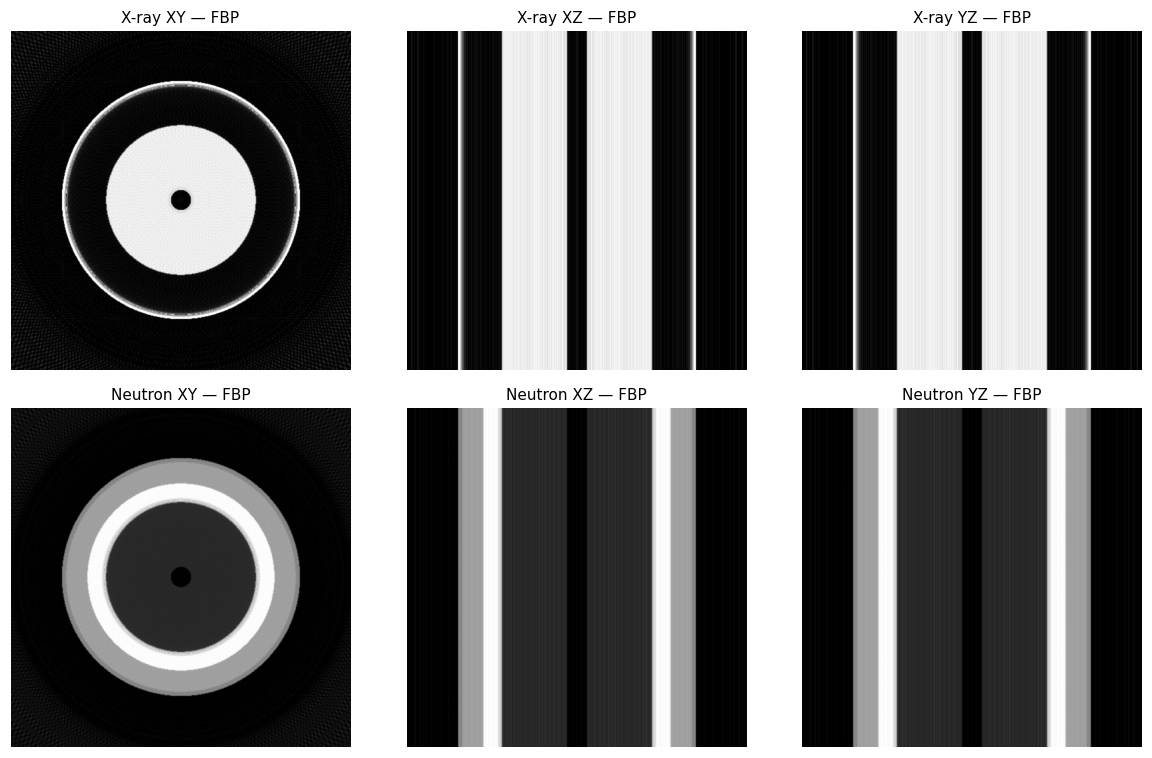

In [17]:
# ── Reconstructed central slices ──────────────────────────────────────────
si = N // 2
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for col, (vx_sl, vn_sl, lbl) in enumerate([
        (vol_x[si],       vol_n[si],       'XY'),
        (vol_x[:, si, :], vol_n[:, si, :], 'XZ'),
        (vol_x[:, :, si], vol_n[:, :, si], 'YZ'),
]):
    vmin_x, vmax_x = np.percentile(vol_x, [1, 99])
    vmin_n, vmax_n = np.percentile(vol_n, [1, 99])
    axes[0, col].imshow(vx_sl, cmap='gray', vmin=vmin_x, vmax=vmax_x)
    axes[0, col].set_title(f'X-ray {lbl} — {ALGORITHM}'); axes[0, col].axis('off')
    axes[1, col].imshow(vn_sl, cmap='gray', vmin=vmin_n, vmax=vmax_n)
    axes[1, col].set_title(f'Neutron {lbl} — {ALGORITHM}'); axes[1, col].axis('off')
plt.tight_layout(); plt.show()


In [22]:
hist = nxs.compute_bimodal_histogram(vol_x, vol_n, bins=128)
print(f'Histogram shape: {hist.H.shape}  total voxels: {hist.total_voxels:,}')


Histogram shape: (128, 128)  total voxels: 134,217,728


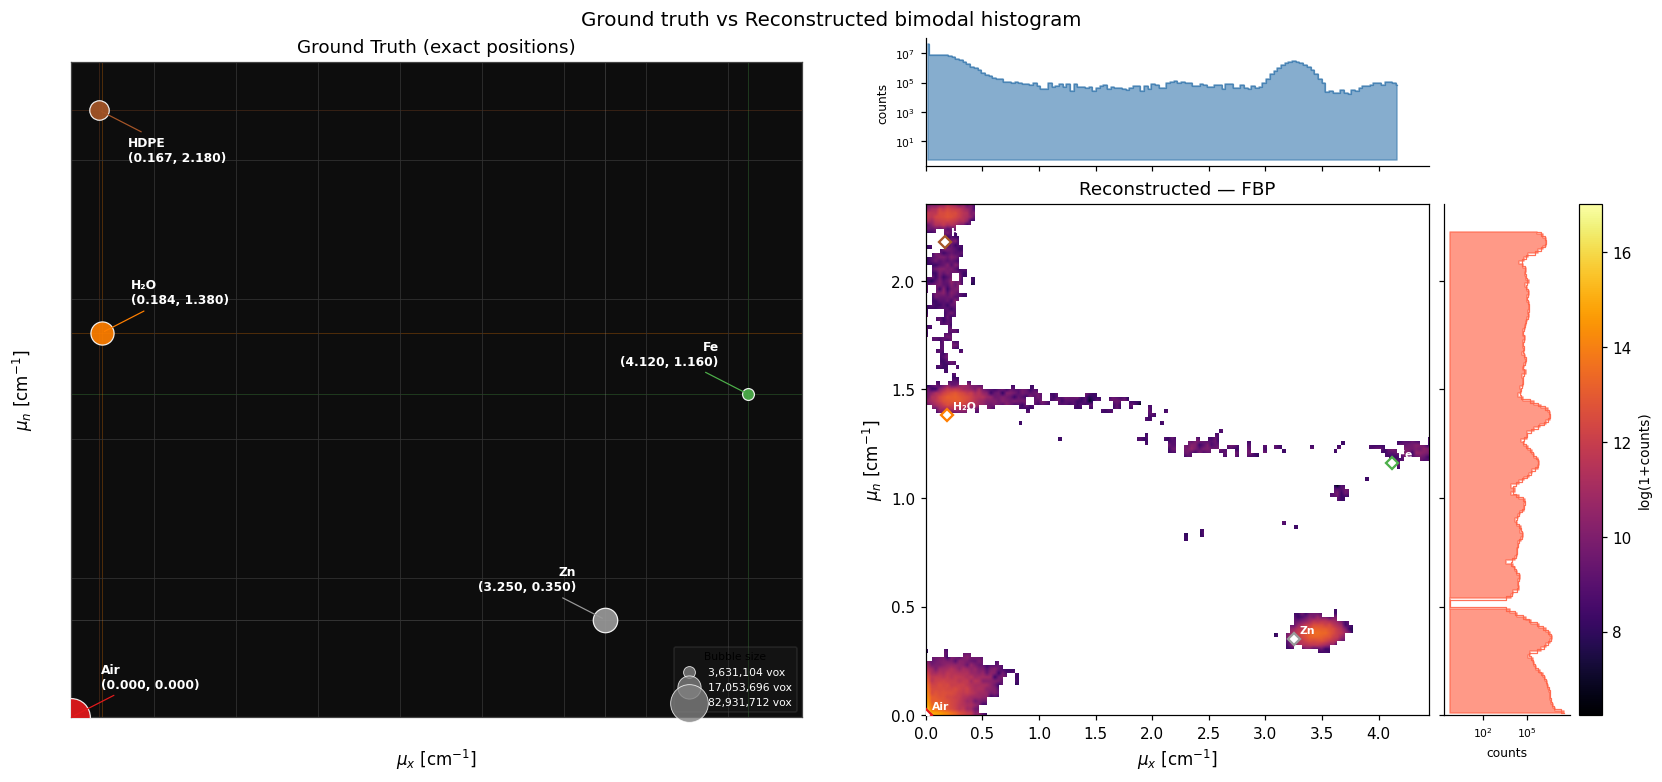

In [24]:
# Ground truth vs reconstruction
gt_hist = nxs.compute_ground_truth_histogram(phantom, bins=128)
fig = nxs.plot_ground_truth_comparison(
    phantom, hist,
    title_gt    = 'Ground Truth (exact positions)',
    title_recon = f'Reconstructed — {ALGORITHM}',
    show_marginals = True,
)
plt.show()


### new visualization 

1. visualize histogram for phantom , xCT and nCT 
2. visualize middle slice for each . 
3. subtract them form one another and visualize them 
4. make a mask around the reconstruction and visualize the histograms again 



In [ ]:
# the energies stored in phantom [20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 150, 200, 300]

In [23]:
print(phantom[6] )
print(vol_n)
print(vol_x)

PhantomData('battery', 512³, 0.002734375 cm/voxel, materials=[Air, Fe, H₂O, HDPE, Zn])
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [

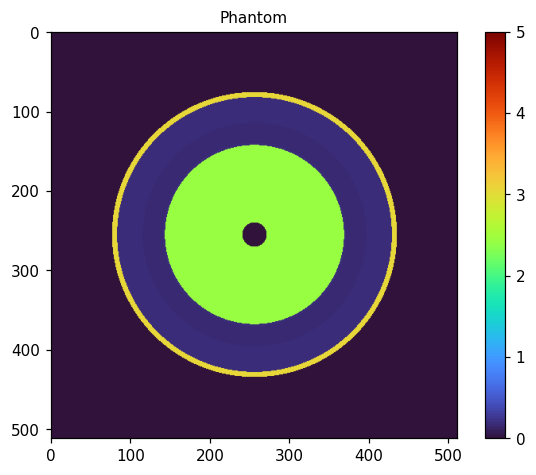

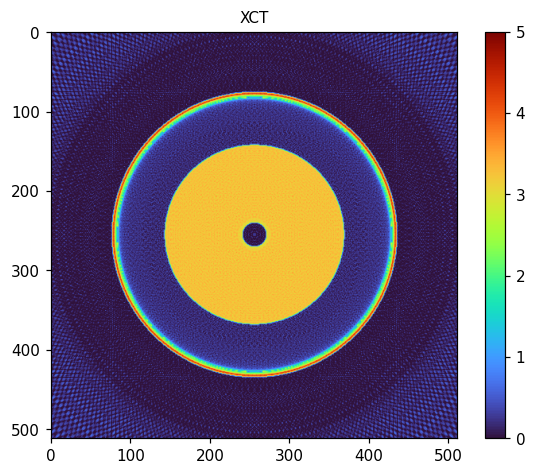

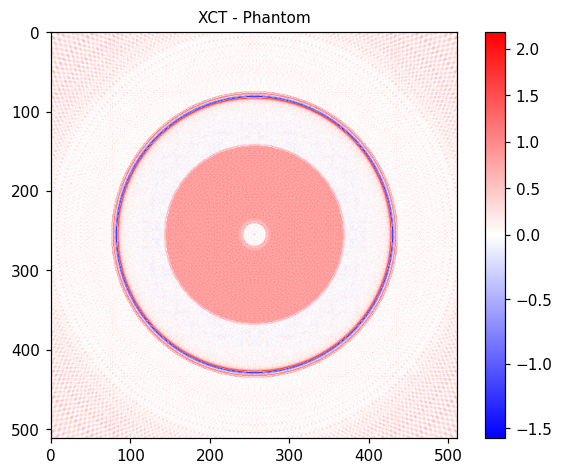

In [47]:
slice_no = 256
slice_x_ray =vol_x[slice_no,:,:]
slice_phantom = phantom.mu_x_vols [7, slice_no, : , :]
slice_n = vol_n[slice_no,:,:]


import matplotlib.colors as mcolors
def plot_normalized ( data , cmap = 'bwr',  titel = 'normalized'):

    plt.title(titel)
    norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
    plt.imshow(data, cmap=cmap, norm=norm)
    plt.colorbar()


norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.5, vmax=5)

plt.figure(1)
plt.title('Phantom')
plt.imshow(slice_phantom , cmap='turbo' , norm=norm)
plt.colorbar()
plt.figure(2)


plt.title('XCT')
plt.imshow( slice_x_ray , cmap='turbo' , norm=norm )
plt.colorbar()

plt.figure(4)
plot_normalized(slice_x_ray - slice_phantom , titel='XCT - Phantom')

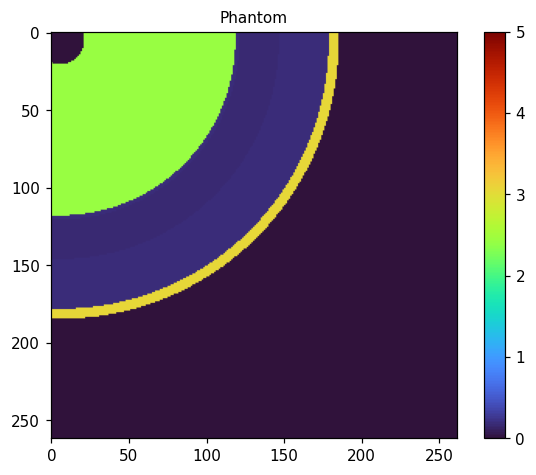

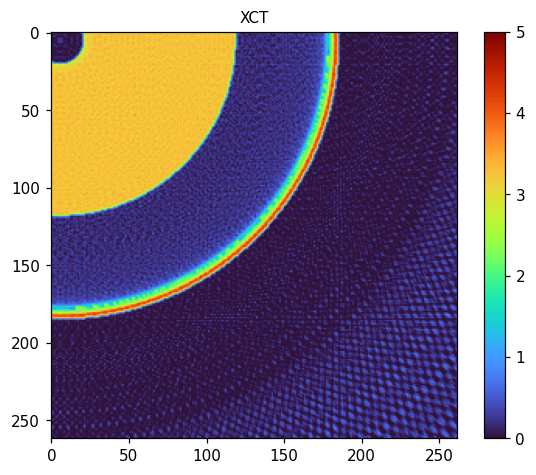

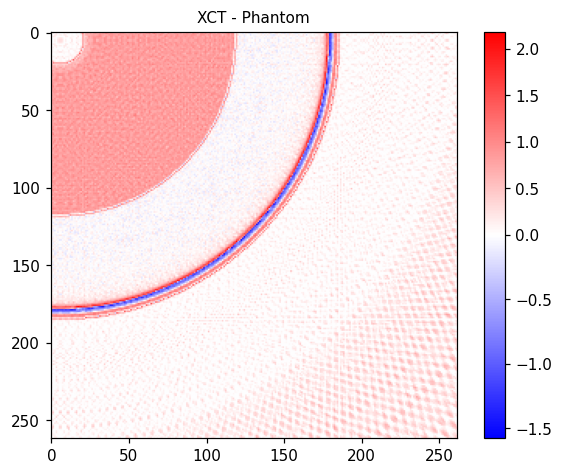

In [51]:
slice_no = 256
slice_x_ray =vol_x[slice_no,250:,250:]
slice_phantom = phantom.mu_x_vols [7, slice_no, 250: , 250:]
slice_n = vol_n[slice_no,250:,250:]


import matplotlib.colors as mcolors
def plot_normalized ( data , cmap = 'bwr',  titel = 'normalized'):

    plt.title(titel)
    norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
    plt.imshow(data, cmap=cmap, norm=norm)
    plt.colorbar()


norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.5, vmax=5)

plt.figure(1)
plt.title('Phantom')
plt.imshow(slice_phantom , cmap='turbo' , norm=norm)
plt.colorbar()
plt.figure(2)


plt.title('XCT')
plt.imshow( slice_x_ray , cmap='turbo' , norm=norm )
plt.colorbar()

plt.figure(4)
plot_normalized(slice_x_ray - slice_phantom , titel='XCT - Phantom')

### Neutrons 

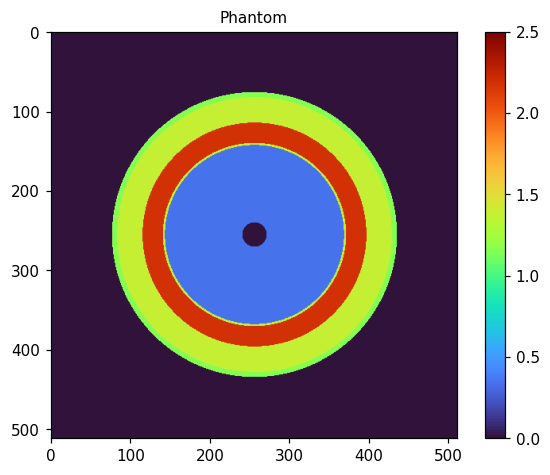

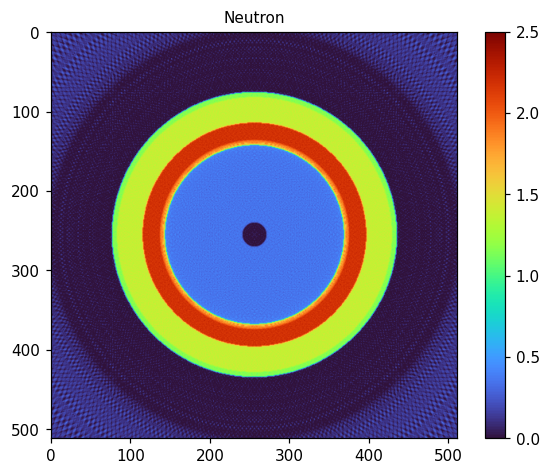

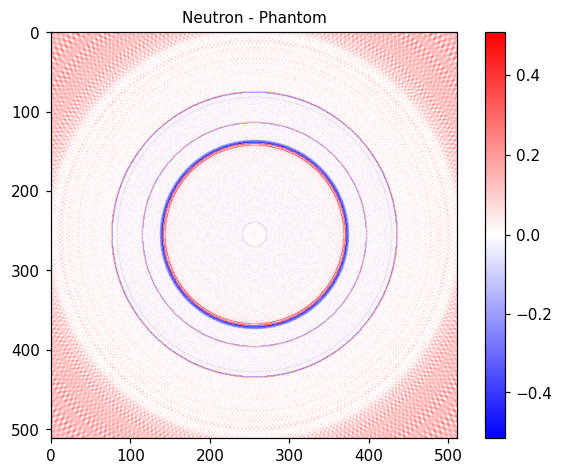

In [50]:



slice_no = 256
slice_x_ray =vol_x[slice_no,:,:]
slice_phantom = phantom.mu_x_vols [7, slice_no, : , :]
slice_phantom_n = phantom.mu_n_vol [slice_no , : , :] 
slice_n = vol_n[slice_no,:,:]


import matplotlib.colors as mcolors
def plot_normalized ( data , cmap = 'bwr',  titel = 'normalized'):

    plt.title(titel)
    norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
    plt.imshow(data, cmap=cmap, norm=norm)
    plt.colorbar()


norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.25, vmax=2.5)

plt.figure(1)
plt.title('Phantom')
plt.imshow(slice_phantom_n , cmap='turbo' , norm=norm)
plt.colorbar()
plt.figure(2)


plt.title('Neutron')
plt.imshow( slice_n , cmap='turbo', norm=norm )
plt.colorbar()

plt.figure(4)
plot_normalized(slice_n - slice_phantom_n , titel='Neutron - Phantom')

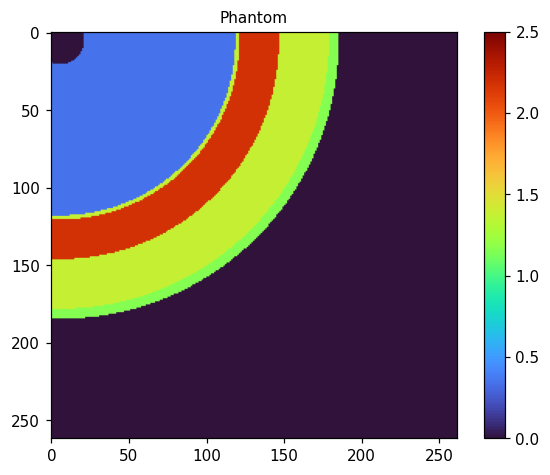

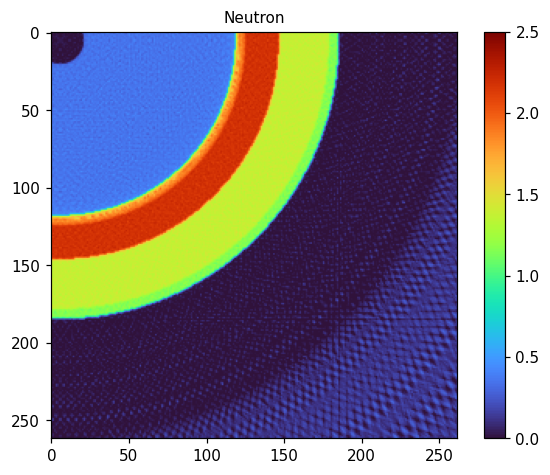

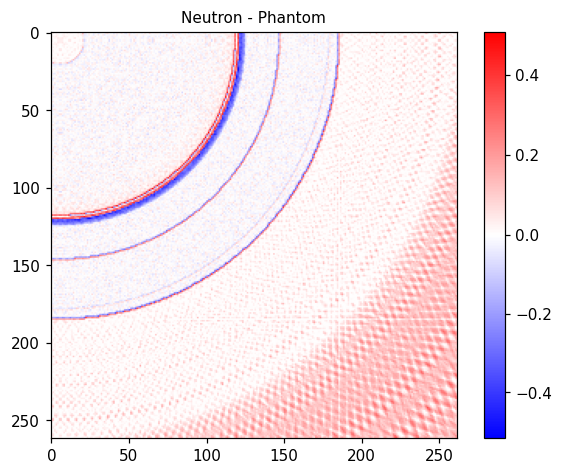

In [52]:



slice_no = 256
slice_x_ray =vol_x[slice_no,250:,:250]
slice_phantom = phantom.mu_x_vols [7, slice_no, 250: , 250:]
slice_phantom_n = phantom.mu_n_vol [slice_no , 250: , 250:] 
slice_n = vol_n[slice_no,250:,250:]


import matplotlib.colors as mcolors
def plot_normalized ( data , cmap = 'bwr',  titel = 'normalized'):

    plt.title(titel)
    norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
    plt.imshow(data, cmap=cmap, norm=norm)
    plt.colorbar()


norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.25, vmax=2.5)

plt.figure(1)
plt.title('Phantom')
plt.imshow(slice_phantom_n , cmap='turbo' , norm=norm)
plt.colorbar()
plt.figure(2)


plt.title('Neutron')
plt.imshow( slice_n , cmap='turbo', norm=norm )
plt.colorbar()

plt.figure(4)
plot_normalized(slice_n - slice_phantom_n , titel='Neutron - Phantom')